In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import dist
from haversine import haversine

In [148]:
STD_THRESHOLD = 1
CLOSENESS_THRESHOLD = 0.2

In [149]:
df_rds = pd.read_csv("../data/raw/_roads.tsv", sep = "\t", low_memory=False)
# df_rds.describe()

In [150]:
df_rds.head()

,road,lrp1,lat1,lon1,lrp2,lat2,lon2,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 4035,Unnamed: 4036,Unnamed: 4037,Unnamed: 4038,Unnamed: 4039,Unnamed: 4040,Unnamed: 4041,Unnamed: 4042,Unnamed: 4043,Unnamed: 4044
0,N1,LRPS,23.706028,90.443333,LRPSa,23.702917,90.450417,LRPSb,23.702778,90.450472,...,92.29825,LRP466c,20.864667,92.298194,LRP467,20.862972,92.298083,LRPE,20.862917,92.298083
1,N101,LRPS,23.454139,91.212861,LRPSa,23.461889,91.212000,LRP001,23.462944,91.211806,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N102,LRPS,23.478972,91.118194,LRPSa,23.481583,91.116777,LRPSb,23.486666,91.113361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N103,LRPS,23.957028,91.115528,LRP001,23.961917,91.113611,LRP001a,23.967666,91.111889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N104,LRPS,23.009667,91.399416,LRPSa,23.009278,91.395250,LRP001,23.009306,91.389805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [151]:
df_rds.tail()

,road,lrp1,lat1,lon1,lrp2,lat2,lon2,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 4035,Unnamed: 4036,Unnamed: 4037,Unnamed: 4038,Unnamed: 4039,Unnamed: 4040,Unnamed: 4041,Unnamed: 4042,Unnamed: 4043,Unnamed: 4044
880,Z8910,LRPS,22.674722,90.408889,LRPSa,22.675916,90.412556,LRP001,22.675583,90.417166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
881,Z8913,LRPS,22.396083,90.688666,LRPSa,22.393027,90.688944,LRPSb,22.392666,90.689083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
882,Z8915,LRPS,22.589389,90.619472,LRP001,22.589694,90.623360,LRP001a,22.590027,90.631360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
883,Z8916,LRPS,22.625499,90.661722,LRPSa,22.623888,90.664167,LRP001,22.620305,90.668999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
884,Z8943,LRPS,22.426444,90.849472,LRPSa,22.426416,90.846833,LRP001,22.425444,90.839861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [152]:
all_data = []

for rd in df_rds.itertuples(index=False):
    rd_name = rd[0]

    for i in range(1, len(rd)-2, 3):
        lrp = rd[i]
        lat = rd[i+1]
        lon = rd[i+2]

        if pd.isna(lrp) and pd.isna(lat) and pd.isna(lon):
            continue

        all_data.append((rd_name, lrp, lat, lon))

df_all = pd.DataFrame(all_data, columns=["road", "LRP", "LAT", "LON"])

print(df_all)


        road      LRP        LAT        LON
0         N1     LRPS  23.706028  90.443333
1         N1    LRPSa  23.702917  90.450417
2         N1    LRPSb  23.702778  90.450472
3         N1   LRP001  23.702139  90.451972
4         N1   LRP002  23.697889  90.460583
...      ...      ...        ...        ...
52205  Z8943   LRP007  22.429499  90.785722
52206  Z8943   LRP008  22.430110  90.776333
52207  Z8943  LRP008a  22.430249  90.774888
52208  Z8943  LRP008b  22.430249  90.774860
52209  Z8943     LRPE  22.430166  90.768916

[52210 rows x 4 columns]


In [153]:
df_all.isna().sum()

road    0
LRP     0
LAT     0
LON     0
dtype: int64

In [154]:
df_rd1 = df_all[df_all["road"] == "N1"]

<Axes: title={'center': 'N1'}, xlabel='LON'>

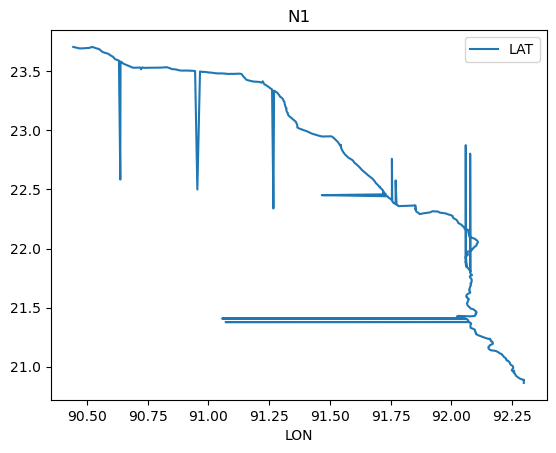

In [155]:
df_rd1.plot(x="LON", y="LAT", title=f'{df_rd1.iloc[0].road}')

In [156]:
df_rd1.describe()

,LAT,LON
count,1348.000000,1348.000000
mean,22.210546,91.738093
std,0.895552,0.506570
min,20.862917,90.443333
25%,21.383632,91.374687
50%,22.212375,92.027652
75%,22.997764,92.094923
max,23.706083,92.299639


In [157]:
def calc_outliers(dataframe_road):
    dist_dict = {}
    outliers_road = []
    for i in range(0, len(dataframe_road) - 1, 1):
        point1 = dataframe_road.iloc[i]
        point2 = dataframe_road.iloc[i+1]
        coord1 = (point1.LAT, point1.LON)
        coord2 = (point2.LAT, point2.LON)
        distance = haversine(coord1, coord2)
        dist_dict[(point1.LRP, point2.LRP)] = distance

        median_road = np.median(list(dist_dict.values()))
        std_road = np.std(list(dist_dict.values()))

    for (LRP1, LRP2), distance in dist_dict.items():
        if distance > median_road + STD_THRESHOLD * std_road:
            outliers_road.append((LRP1, LRP2, distance)) 
    return outliers_road, median_road, std_road

# outliers_r, median_r, std_r = calc_outliers(df_rd1)

In [158]:
def calc_lrp_outliers(outliers, std):
    lrp_outliers = []
    if outliers[0][0] == 'LRPS':
        lrp1, lrp2, dist = outliers[0]
        lrp_outliers.append(lrp1)
        print(lrp_outliers)
        outliers = outliers[1:]

    for i in range(0, len(outliers) - 1, 1):
        lrp1, lrp2, dist = outliers[i]
        lrp2_2, lrp3, dist2 = outliers[i+1]
        if lrp2 == lrp2_2:
            print(f'De outlier is {lrp2}')
            lrp_outliers.append(lrp2)
        else:
            if abs(dist - dist2) < CLOSENESS_THRESHOLD * std:
                print(f'De outlier is {lrp2} maar ook {lrp2_2} is een outlier')
                lrp_outliers.append(lrp2)
                lrp_outliers.append(lrp2_2)
    return lrp_outliers

In [159]:
# # lrp_outliers
# lrp_outliers_r = calc_lrp_outliers(outliers_r)
# df_rd1_outliers = df_rd1[df_rd1["LRP"].isin(lrp_outliers_r)]
# df_rd1_outliers

In [160]:
# 1. Create the copy ONCE before the loop starts
# We will modify this dataframe cumulatively

def snap_point(lrp, df_to_fix, pos_idx, lrp_outliers):
    # USE LENGTH, NOT INDEX.MAX()
    # 'pos_idx' is 0, 1, 2... so max position is len() - 1
    max_pos = len(df_to_fix) - 1
    
    # -------------------------------------------------------
    # 1. Determine Neighbors & Mode based on POSITION
    # -------------------------------------------------------
    if pos_idx == 0:
        n1_pos = pos_idx + 1
        n2_pos = pos_idx + 2
        mode = 'extrapolate_backward' # Fixing Start

    elif pos_idx == max_pos:
        n1_pos = pos_idx - 1
        n2_pos = pos_idx - 2
        mode = 'extrapolate_forward'  # Fixing End

    else:
        n1_pos = pos_idx - 1
        n2_pos = pos_idx + 1
        mode = 'interpolate'          # Fixing Middle

    # -------------------------------------------------------
    # 2. Skip Bad Neighbors (Safety Check)
    # -------------------------------------------------------
    # Note: We read from df_to_fix (which might already have some fixes!)
    
    # Check Neighbor 1
    if df_to_fix.iloc[n1_pos]['LRP'] in lrp_outliers:
        step = 1 if n1_pos > pos_idx else -1
        n1_pos += step
    
    # Check Neighbor 2
    # Ensure n2_pos is still valid before checking
    if 0 <= n2_pos <= max_pos and df_to_fix.iloc[n2_pos]['LRP'] in lrp_outliers:
        step = 1 if n2_pos > pos_idx else -1
        n2_pos += step

    # Final Boundary Check
    if not (0 <= n1_pos <= max_pos) or not (0 <= n2_pos <= max_pos):
        print(f"Cannot fix {lrp}: Neighbors unavailable.")
        return

    # -------------------------------------------------------
    # 3. Calculate Logic (using iloc for positions)
    # -------------------------------------------------------
    p1 = df_to_fix.iloc[n1_pos]
    p2 = df_to_fix.iloc[n2_pos]
    curr_pt = df_to_fix.iloc[pos_idx]
    # print(f'{curr_pt} has neighbour {p1} and neighbour {p2}')

    # Calculate Expected Values
    if mode == 'interpolate':
        exp_lat = (p1['LAT'] + p2['LAT']) / 2.0
        exp_lon = (p1['LON'] + p2['LON']) / 2.0
        
    else: 
        # Both Extrapolations use the same vector logic: P1 + (Vector P2->P1)
        # P1 is the closer neighbor, P2 is the farther one.
        exp_lat = p1['LAT'] + (p1['LAT'] - p2['LAT'])
        exp_lon = p1['LON'] + (p1['LON'] - p2['LON'])

    # -------------------------------------------------------
    # 4. Apply Fix (Converting Position -> Label)
    # -------------------------------------------------------
    lat_diff = abs(curr_pt['LAT'] - exp_lat)
    lon_diff = abs(curr_pt['LON'] - exp_lon)

    # CRITICAL: We need the LABEL index (e.g., 1348) to write with .at[]
    real_label_index = df_to_fix.index[pos_idx]

    if lat_diff > lon_diff:
        print(f"Fixing {lrp} (Pos {pos_idx}): Snapped LAT to {exp_lat:.4f}")
        # Use real_label_index here!
        df_to_fix.at[real_label_index, 'LAT'] = exp_lat
    else:
        print(f"Fixing {lrp} (Pos {pos_idx}): Snapped LON to {exp_lon:.4f}")
        df_to_fix.at[real_label_index, 'LON'] = exp_lon


# --- MAIN LOOP ---
def fix_outliers(dataframe, lrp_outliers):
    df_cleaned = dataframe.copy()
    for outlier in lrp_outliers:
        # 1. Find Integer Position (0, 1, 2...)
        row_pos_array = np.where(df_rd1['LRP'] == outlier)[0]
        if len(row_pos_array) > 0:
            row_pos = row_pos_array[0]
            # 2. Pass the CLEAN dataframe (df_cleaned) to be modified in place
            snap_point(outlier, df_cleaned, row_pos, lrp_outliers)
        else:
            print(f"Outlier {outlier} not found in dataframe.")
    return df_cleaned

# df_clean = fix_outliers(df_rd1, lrp_outliers_r)
# Plot the result
# df_cleaned.plot(x="LON", y="LAT", kind='scatter', title="Fixed Road")

In [161]:
# f, axes = plt.subplots(1,2, figsize=(12, 6), sharey=True)
# axes.flatten()
# axes[0].plot(df_rd1['LON'], df_rd1['LAT'], marker='o', label='Original N1')
# axes[0].set_title(f'Original {df_rd1.iloc[0].road}')
# axes[1].plot(df_clean['LON'], df_clean['LAT'],  label='Snapped N1')
# axes[1].set_title(f'Snapped {df_rd1.iloc[0].road}')

def check_lists(list1, list2):
    for i in range(0, len(list1)):
        lrp1, lrp2, dist1 = list1[i]
        lrp1_2, lrp2_2, dist1_2 = list2[i]
        if lrp1 != lrp1_2 or lrp2 != lrp2_2:
            return False
    return True
        

In [162]:
outliers_present = True
df_rd1_copy = df_rd1.copy()
outliers_n, median_n, std_n = calc_outliers(df_rd1_copy)
outliers_copy = [(0,0), (0,0)]
iteration = 1
while outliers_present:
    print(f'Started iteration {iteration}')
    if len(outliers_n) == len(outliers_copy) and check_lists(outliers_copy, outliers_n):
        outliers_present = False
        print(f'Finished at iteration {iteration} as outliers are the same.')
        print(f'{outliers_n} and {outliers_copy}')
        print(f'{len(outliers_n)} ')
        break
    outliers_n, median_n, std_n = calc_outliers(df_rd1_copy)
    lrp_outliers_n = calc_lrp_outliers(outliers_n, std_n)
    print(len(lrp_outliers_n))
    if len(lrp_outliers_n) == 0:
        outliers_present = False
        break
    df_rd1_copy = fix_outliers(df_rd1_copy, lrp_outliers_n)
    outliers_copy = outliers_n.copy()
    iteration = iteration + 1
    
print(f'Finished!')


Started iteration 1
De outlier is LRP027a
De outlier is LRP028 maar ook LRP064 is een outlier
De outlier is LRP065
De outlier is LRP066 maar ook LRP107 is een outlier
De outlier is LRP108
De outlier is LRP225
De outlier is LRP230c
De outlier is LRP234b
De outlier is LRP323a maar ook LRP324 is een outlier
De outlier is LRP324a maar ook LRP331c is een outlier
De outlier is LRP332
De outlier is LRP391a
De outlier is LRP391b maar ook LRP395a is een outlier
De outlier is LRP395b
19
Fixing LRP027a (Pos 69): Snapped LAT to 23.5861
Fixing LRP028 (Pos 70): Snapped LAT to 23.5861
Fixing LRP064 (Pos 153): Snapped LON to 90.9532
Fixing LRP065 (Pos 154): Snapped LAT to 23.5005
Fixing LRP066 (Pos 155): Snapped LON to 90.9596
Fixing LRP107 (Pos 232): Snapped LAT to 23.3423
Fixing LRP108 (Pos 233): Snapped LAT to 23.3423
Fixing LRP225 (Pos 538): Snapped LON to 91.7334
Fixing LRP230c (Pos 553): Snapped LAT to 22.4058
Fixing LRP234b (Pos 567): Snapped LAT to 22.3728
Fixing LRP323a (Pos 792): Snapped LAT

In [163]:
print(outliers_n, std_n, median_n)

[('LRP027', 'LRP027a', 111.84824949348993), ('LRP027a', 'LRP028', 111.0931563552762), ('LRP064', 'LRP065', 111.47715734515256), ('LRP065', 'LRP066', 111.10189753970427), ('LRP107', 'LRP108', 112.00885901900824), ('LRP108', 'LRP108a', 110.85878398839243), ('LRP224b', 'LRP225', 27.125845116647483), ('LRP225', 'LRP226', 27.743799565331084), ('LRP230b', 'LRP230c', 38.91827808173692), ('LRP230c', 'LRP231', 39.49613835055684), ('LRP234a', 'LRP234b', 22.223573981856408), ('LRP234b', 'LRP235', 23.038998591457002), ('LRP323', 'LRP323a', 110.69470240938722), ('LRP324', 'LRP324a', 112.08456918919227), ('LRP331c', 'LRP332', 111.18272646011935), ('LRP332', 'LRP333', 112.16504868589224), ('LRP391', 'LRP391a', 103.39328221435402), ('LRP391a', 'LRP391b', 103.63281970344522), ('LRP395a', 'LRP395b', 103.54128418106178), ('LRP395b', 'LRP395c', 103.57047493461667)] 11.220423429034534 0.2491087506965481


Text(0.5, 1.0, 'Snapped N1')

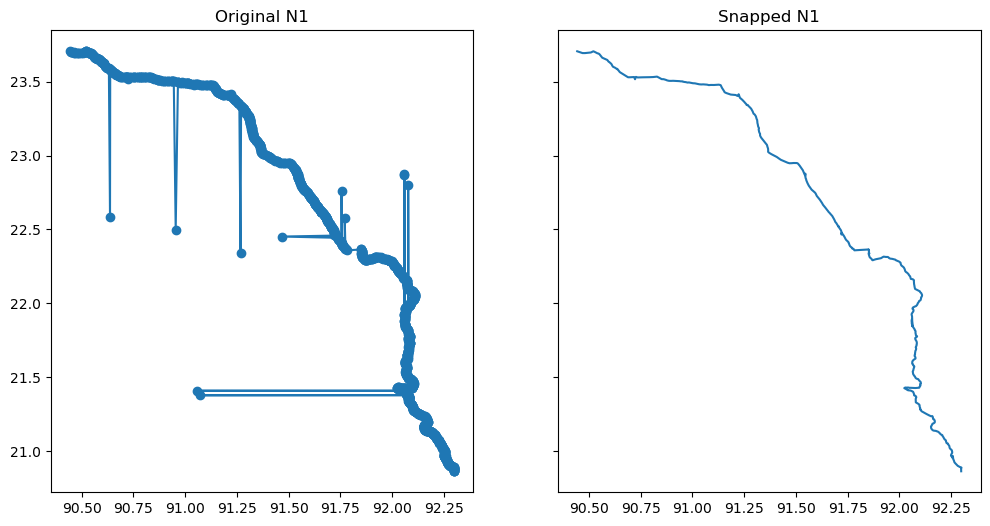

In [164]:
f, axes = plt.subplots(1,2, figsize=(12, 6), sharey=True)
axes.flatten()
axes[0].plot(df_rd1['LON'], df_rd1['LAT'], marker='o', label='Original N1')
axes[0].set_title(f'Original {df_rd1.iloc[0].road}')
axes[1].plot(df_rd1_copy['LON'], df_rd1_copy ['LAT'],  label='Snapped N1')
axes[1].set_title(f'Snapped {df_rd1.iloc[0].road}')

In [165]:
# def snap_point(lrp, df_rd, index):
#     max_index = df_rd.index.max()
#     df_rd_copy = df_rd.copy()
#     print(max_index)

#     if index == 0:
#         n1_idx = index + 1
#         n2_idx = index + 2
#         mode = 'extrapolate_backward'

#     elif index == max_index:
#         n1_idx = index - 1
#         n2_idx = index - 2
#         mode = 'extrapolate_forward'

#     else:
#         n1_idx = index - 1
#         n2_idx = index + 1
#         mode = 'interpolate'

#     if df_rd.iloc[n1_idx]['LRP'] in lrp_outliers:
#         # If n1 is bad, shift it further away by 1
#         step = 1 if n1_idx > index else -1
#         n1_idx += step 
    
#     # Check Neighbor 2 (Only if still in bounds)
#     if 0 <= n2_idx <= max_index and df_rd.iloc[n2_idx]['LRP'] in lrp_outliers:
#         step = 1 if n2_idx > index else -1
#         n2_idx += step

#     # Final Boundary Safety Check (if skipping pushed us off the map)
#     if not (0 <= n1_idx <= max_index) or not (0 <= n2_idx <= max_index):
#         print(f"Cannot fix Index {index}: Neighbors unavailable or invalid.")
#         return

#     p1 = df_rd.iloc[n1_idx]
#     p2 = df_rd.iloc[n2_idx]
#     curr_pt = df_rd.iloc[index]

#     if mode == 'interpolate':
#         # Average of neighbors (The Sandwich Method)
#         exp_lat = (p1['LAT'] + p2['LAT']) / 2.0
#         exp_lon = (p1['LON'] + p2['LON']) / 2.0
        
#     elif mode == 'extrapolate_backward':
#         # Predict 0 using the slope of 2 -> 1
#         # Logic: Expected = P1 + (P1 - P2)
#         exp_lat = p1['LAT'] + (p1['LAT'] - p2['LAT'])
#         exp_lon = p1['LON'] + (p1['LON'] - p2['LON'])
        
#     elif mode == 'extrapolate_forward':
#         # Predict End using the slope of (End-2) -> (End-1)
#         # Logic: Expected = P1 + (P1 - P2)  (Since P1 is closer to target than P2)
#         exp_lat = p1['LAT'] + (p1['LAT'] - p2['LAT'])
#         exp_lon = p1['LON'] + (p1['LON'] - p2['LON'])

#     # 4. Calculate Deviations (How far off is the current point?)
#     # We use absolute difference

#     lat_diff = abs(curr_pt['LAT'] - exp_lat)
#     lon_diff = abs(curr_pt['LON'] - exp_lon)

#     if lat_diff > lon_diff:
#         print(f"Index {index}: Fixed LAT based on {mode}")
#         print(f"Original LAT: {curr_pt['LAT']}, Expected LAT: {exp_lat}, Deviation: {lat_diff}")
#         df_rd_copy.at[index, 'LAT'] = exp_lat
#         print(df_rd_copy.at[index, 'LAT'])
#     else:
#         print(f"Index {index}: Fixed LON based on {mode}")
#         df_rd_copy.at[index, 'LON'] = exp_lon
#     return df_rd_copy

# for outlier in lrp_outliers:
#     row_pos_array = np.where(df_rd1['LRP'] == outlier)[0]
#     if len(row_pos_array) > 0:
#         row_pos = row_pos_array[0]
        
#         # 2. Get the "Real" Index Label (1348, 1356) for your reference
#         # We look up the label that sits at that integer position
#         real_index = df_rd1.index[row_pos]
        
#         print(f"LRP {outlier}: Row Pos {row_pos} | Original Index {real_index}")
        
#         # IMPORTANT: Pass 'row_pos' (0), not 'real_index' (1348)
#         # Your snap_point function uses .iloc, which expects 0, 1, 2...
#         df_rd1_copy = snap_point(outlier, df_rd1, row_pos)

# # df_rd1_copy.plot(x="LON", y="LAT", title="N1 Snapped")


